# Analysis of the Human Protein–Protein Interaction Network Using Graph Theory and Machine Learning

**Course:** Network Science  
**Student:** Rodrigo Sousa  
**Dataset:** STRING v12.0 — *Homo sapiens* (9606)  
**Files:** `9606.protein.links.detailed.v12.0.txt.gz` + `9606.protein.info.v12.0.txt.gz`

---

## Project Goal
Model and analyze the human Protein–Protein Interaction (PPI) network using graph theory:
- Build an **undirected, weighted** graph (proteins = nodes, interactions = edges).
- Compute **descriptive metrics** (size, density, degree distribution, clustering coefficient).
- Identify **key proteins** via centrality measures.
- Detect **functional communities** (with the Louvain ALgortithm and Node2vec + K-means).
- (ML) Perform **link prediction** using **Node2Vec** embeddings + Logistic Regression and Random Forest Classifier.

### Why this network?
Biological networks are modular, sparse, and robust. Hubs and bridges often correspond to essential proteins or cross-talk between pathways. This makes PPI a natural and meaningful application of network theory.

> **Graph definition:** Undirected weighted graph G=(V,E) where V are proteins and E indicates an interaction supported by STRING. Edge weight = `combined_score` (confidence 0–1000).


In [43]:
#----------------------------------#----------------------------------#----------------------------------
# Libraries Used and Imports
#----------------------------------#----------------------------------#----------------------------------
import node2vec
import pandas as pd
import numpy as np
import networkx as nx
import scipy as sp
import seaborn as sns
from node2vec import Node2Vec
import random
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import normalized_mutual_info_score
from scipy.stats import sem, loguniform, beta, uniform
import matplotlib
import matplotlib.pyplot as plt
import os
import pickle
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix
)
#----------------------------------#----------------------------------#----------------------------------
#Reproducibility for stable results in Louvain, Node2Vec, K-means, splits
#By fixing a SEED and using random_state=SEED
#----------------------------------#----------------------------------#----------------------------------
SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)

### Reading the files

In [44]:
#----------------------------------#----------------------------------#----------------------------------
#Loading the string(Homo sapien protein interactions) files
#----------------------------------#----------------------------------#----------------------------------
LINKS_PATH = "9606.protein.links.detailed.v12.0.txt.gz" #this file contains the edges that we will use to create the main graph
INFO_PATH  = "9606.protein.info.v12.0.txt.gz" #this file contains aditional metadata on the proteins, for example, legible names and contextual information

ppi = pd.read_csv(LINKS_PATH, sep=r"\s+") #Reading links, cols separated by spaces 
print("Links shape:", ppi.shape) #Number links/rows
print("Links columns:", list(ppi.columns)[:12]) 

info = pd.read_csv(INFO_PATH, sep="\t") #Reading metadata
print("Info shape:", info.shape) 
print("Info columns:", list(info.columns))

Links shape: (13715404, 10)
Links columns: ['protein1', 'protein2', 'neighborhood', 'fusion', 'cooccurence', 'coexpression', 'experimental', 'database', 'textmining', 'combined_score']
Info shape: (19699, 4)
Info columns: ['#string_protein_id', 'preferred_name', 'protein_size', 'annotation']


### Data cleaning and column selection

Removing self-loops, duplicates.

Filtering only for high confidence (combined_score > x), leaving the dataset lighter and cleaner.

Remaining only the collumns ``protein1, protein2, combined_score`` (subscores ficam guardados no ppi original se precisares)

In [45]:
required_cols = {"protein1", "protein2", "combined_score"} #For the construction of the graph we will use only these columns, the score will represent the edge weight
assert required_cols.issubset(ppi.columns), "The essencial columns aren't in the file 'detailed'." #checks if all the required columns are in the dataframe, 
                                                                                                   #otherwise it will show the error message

#Removing auto-loops (which is the case of a protein interacting with itself) and duplicate edges/interactions
ppi_clean = (
    ppi.loc[ppi["protein1"] != ppi["protein2"], ["protein1","protein2","combined_score"]]
       .drop_duplicates() #ensures unique pairs of (protein1, protein2)
       .copy()
)

#Applying a confidence threshold to keep only strong interactions
#The STRING score ranges from 0 to 1000, where higher = more reliable.
#Threshold bigger than 600 keeps high-confidence edges and makes the graph smaller and cleaner. 
ppi_clean = ppi_clean[ppi_clean["combined_score"] > 600].reset_index(drop=True)

ppi_clean.head(), ppi_clean.shape #displaying the first few rows and the final dataset size (the rows means the edges that were kept in the graph)


(               protein1              protein2  combined_score
 0  9606.ENSP00000000233  9606.ENSP00000310226             648
 1  9606.ENSP00000000233  9606.ENSP00000248901             618
 2  9606.ENSP00000000233  9606.ENSP00000158762             825
 3  9606.ENSP00000000233  9606.ENSP00000239690             622
 4  9606.ENSP00000000233  9606.ENSP00000357048             718,
 (717392, 3))

### Preparing Legible Names

The orginal names in the "detailed.txt" version aren't very human-friendly, therefore we use the metadata available in the ***protein.info*** file to map the IDs to names.\
The columns in ***protein.info*** vary slightly between versions. \
We automatically pick the best available name column.

In [46]:
#The dataframe info contains '#string_protein_id' e 'preferred_name'
id_col   = "#string_protein_id"
name_col = "preferred_name"

#Sanity: garanteeing they exist 
assert id_col in info.columns and name_col in info.columns

#Mapping clean (without NaN nor duplicates)
name_map = (info[[id_col, name_col]]
            .dropna() #No Na
            .drop_duplicates(subset=[id_col]) #No duplicates
            .set_index(id_col)[name_col]
            .to_dict()) #Creates a dictionary with the results {protein_id: protein_legibleName}

#Few Examples
list(name_map.items())[:3]


[('9606.ENSP00000000233', 'ARF5'),
 ('9606.ENSP00000000412', 'M6PR'),
 ('9606.ENSP00000001008', 'FKBP4')]

### Generate the graph

The graph is undirected, since the interaction between two proteins doesn't have a direction.

The links between the nodes (proteins) are weighted and it reflects the confidence level between the interaction of the proteins.

In [ ]:
#----------------------------------#----------------------------------#----------------------------------
#Creating the graph, using the from_pandas_edgelist from the NetworkX library
#Basically it returns a graph from Pandas DataFrame containing an edge list, which is our case
#----------------------------------#----------------------------------#----------------------------------
G = nx.from_pandas_edgelist(
    ppi_clean,                  #uses the clean dataframe version 
    source="protein1",          #node1
    target="protein2",          #node2
    edge_attr="combined_score", #weight
    create_using=nx.Graph()     #undirected Graph
)

#Creating a name attribute (if it exists)
if name_map: #Mapping the name
    nx.set_node_attributes(G, {n: {"name": name_map.get(n, n)} for n in G.nodes})

print(f"Graph built. Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}") #Printing all the nodes and edges of our graphs


#Helper to get a "pretty" name to show an example after
def pretty(n): 
    return G.nodes[n].get("name", n)

#Example: Listing 5 edges from our graph with the "pretty" names and the corresponding weight/combined_score
for u, v, d in list(G.edges(data=True))[:5]:
    print(f"{pretty(u)}  --  {pretty(v)}   (score={d['combined_score']})")




Graph built. Nodes: 17,995 | Edges: 358,696
ARF5  --  RAB1B   (score=648)
ARF5  --  CYTH4   (score=618)
ARF5  --  ACAP1   (score=825)
ARF5  --  NUDCD1   (score=622)
ARF5  --  COPA   (score=718)


### Initial statistics of the network

In [48]:
#----------------------------------#----------------------------------#----------------------------------
#Creating some initial statistics of our network
#----------------------------------#----------------------------------#----------------------------------
num_nodes = G.number_of_nodes() 
num_edges = G.number_of_edges()
density   = nx.density(G) #density of our graph, it essentialy is the the ratio of the number of edges to the maximum possible number of edges in the graph, ranging from 0 to 1-complete graph

#Components-connected subgraphs that are not part of any larger connected subgraph
components = list(nx.connected_components(G)) #listing all of our connected components
num_components = len(components)
largest_cc = max(components, key=len) #Largest connected component
Gcc = G.subgraph(largest_cc).copy() #Generating a subgraph with our greatest connected component

print(f"Nodes: {num_nodes:,}")
print(f"Edges: {num_edges:,}")
print(f"Density: {density:.6f}")
print(f"Connected components: {num_components} | Largest CC size: {Gcc.number_of_nodes():,} nodes, {Gcc.number_of_edges():,} edges")


Nodes: 17,995
Edges: 358,696
Density: 0.002216
Connected components: 62 | Largest CC size: 17,844 nodes, 358,602 edges


The human protein–protein interaction network contains 17,995 proteins and 358,696 interactions.\
The network is very sparse (density ≈ 0.0022) yet almost fully connected, with one giant component comprising **~99% of all nodes**.\
This indicates that most proteins are functionally interconnected, forming a single large biological system, while only a few isolated small clusters exist.

The remaining 61 connected components are small isolated clusters, likely corresponding to poorly characterized or highly specific protein groups.\
Their isolation may reflect either missing experimental data or true functional separation within the biological system.

For this project, our study will be concentrated solely on the largest connected component, as it contains the vast majority of nodes and edges and represents the main structure of the protein–protein interaction network.

### First visualization

This first visualization includes the entirety of the graph, with all its components, which is not very useful, but it's a good starting point to understand it's structure.

In [7]:
nx.write_gexf(G, "first_visualization_ppi.gexf") #creating a gephi file, where we will create the image for the visualization of our ppi graph

### **Figure 1** - First Visualization of the protein-protein interaction graph.


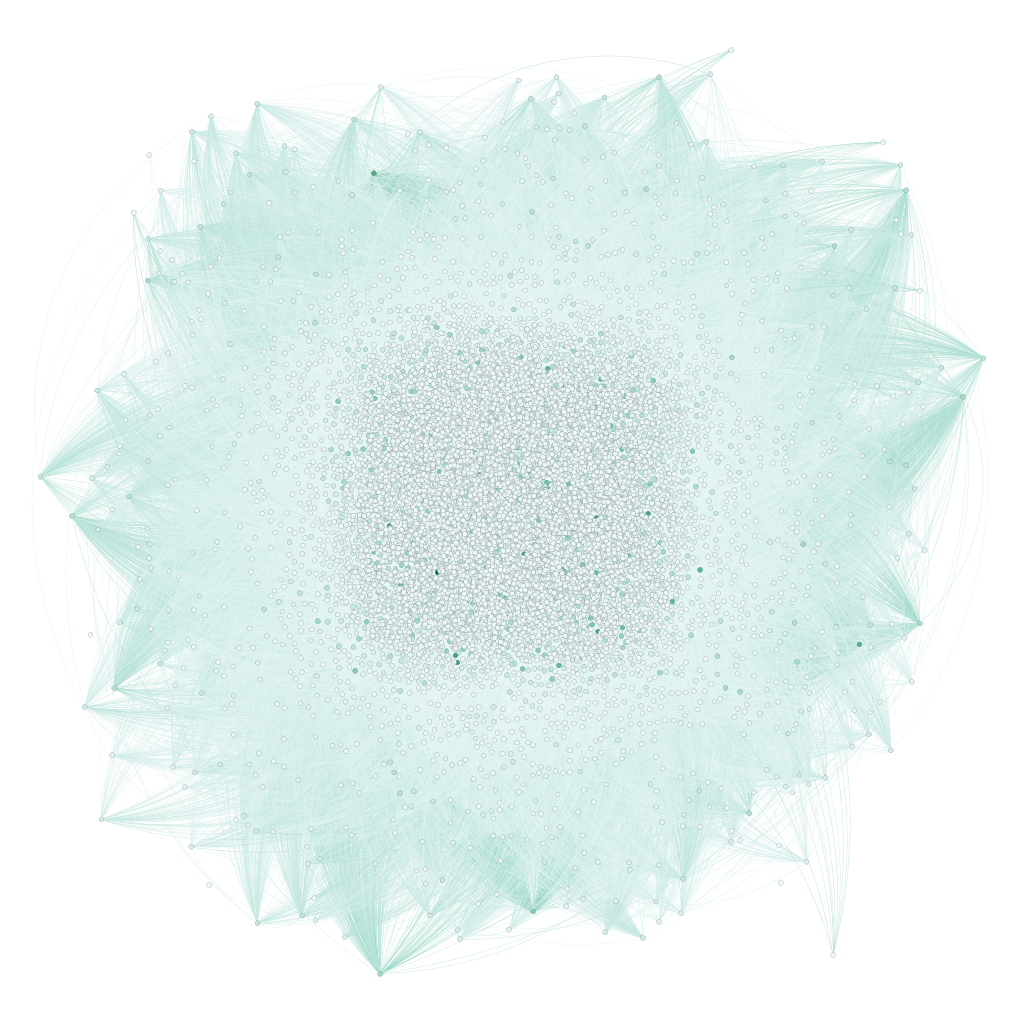

### Distribution of the Degree (of the Largest Connected Component)

The objective of this part is to **understand how node degrees are distributed in the network** and to **check if most proteins have few connections and few are hubs**

Since the graph is undirected, we can only compute the overall degree.

In [49]:
#----------------------------------#----------------------------------#----------------------------------
#Computing the empirical cumulative distribution (ECDF)
#----------------------------------#----------------------------------#----------------------------------

#Extracting the degree (number of neighbors) for each node in the largest connected component
degree_sample = np.array([d for _, d in Gcc.degree()])
x = np.unique(degree_sample) #Get all unique degree values present in the network

#Computing the ECDF: for each degree value 'x',
#Find the proportion of nodes with degree ≤ x.
y = np.searchsorted(np.sort(degree_sample), x, side='right') / degree_sample.size #np.searchsorted finds how many degrees are ≤ each x


### Creating the image for the Degree Distribution of our Network

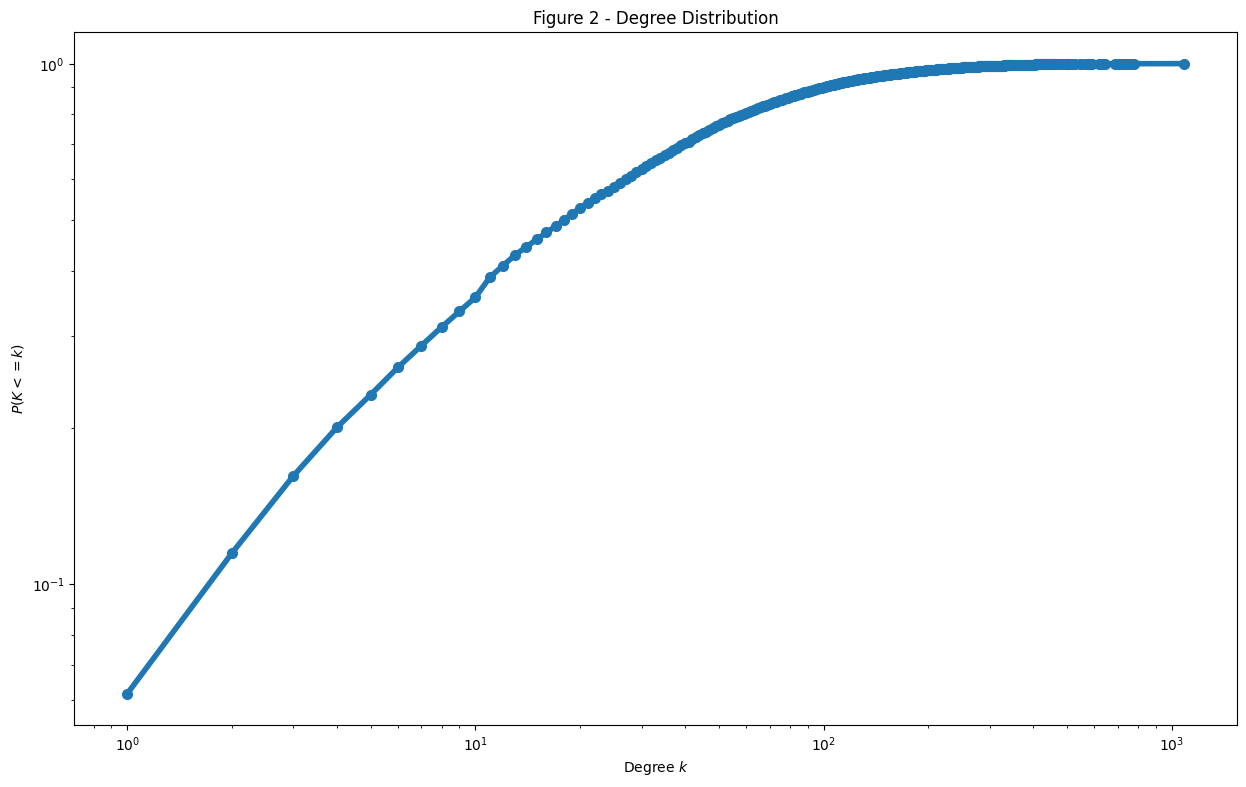

In [51]:
fig = plt.figure(figsize=(15,9)) #defining the size of the figure
ax = fig.add_subplot() 
ax.loglog(x, y, lw=4, ls='-', ms=7, marker='o') #Plot the ECDF curve using a log–log scale -> both axes are logarithmic (better visualization of large ranges)
ax.set_xlabel(r'Degree $k$') #label x
ax.set_ylabel(r'$P(K <= k)$') #label y
ax.set_title("Figure 2 - Degree Distribution")
plt.show()


The empirical cumulative degree distribution shows a heavy-tailed pattern, indicating that while most proteins have few connections, a small number of hub proteins exhibit very high degrees. \
This confirms the typical scale-free structure observed in biological networks, where a few nodes play a central role in maintaining global connectivity.

#### Identifying hub proteins in the network 
Now, the goal is to **detect the top 5% most connected proteins**. These "hubs" usually play key biological roles since they interact with many other proteins

In [52]:
#Computing the degree value corresponding to the 95th percentile
#In other words, any node whose degree is above this threshold is considered a "hub" (top 5% most connected).

hub_threshold = np.percentile(degree_sample, 95)
hubs = {k for k, v in Gcc.degree() if v >= hub_threshold} #creating a set containing the hubs
print(hubs)

{'9606.ENSP00000497733', '9606.ENSP00000309334', '9606.ENSP00000482107', '9606.ENSP00000295897', '9606.ENSP00000384863', '9606.ENSP00000400591', '9606.ENSP00000255631', '9606.ENSP00000363642', '9606.ENSP00000315299', '9606.ENSP00000418082', '9606.ENSP00000378402', '9606.ENSP00000474412', '9606.ENSP00000321797', '9606.ENSP00000303373', '9606.ENSP00000313877', '9606.ENSP00000228347', '9606.ENSP00000379506', '9606.ENSP00000262306', '9606.ENSP00000254719', '9606.ENSP00000362105', '9606.ENSP00000495530', '9606.ENSP00000441543', '9606.ENSP00000382250', '9606.ENSP00000365230', '9606.ENSP00000428924', '9606.ENSP00000332973', '9606.ENSP00000341885', '9606.ENSP00000258955', '9606.ENSP00000451818', '9606.ENSP00000396673', '9606.ENSP00000369424', '9606.ENSP00000226574', '9606.ENSP00000359719', '9606.ENSP00000229795', '9606.ENSP00000319240', '9606.ENSP00000262584', '9606.ENSP00000239690', '9606.ENSP00000332049', '9606.ENSP00000346015', '9606.ENSP00000307567', '9606.ENSP00000345957', '9606.ENSP00000

Now we check if all the hubs form one large interconnected cluster.

In [53]:
#Computing the degree value corresponding to the 95th percentile.
#In other words, any node whose degree is above this threshold
#is considered a "hub" (top 5% most connected).
hubs_ccs = len(list(nx.connected_components(Gcc.subgraph(hubs).copy()))) 
hubs_ccs

1

In this case all the hub nodes are connected through at least one path made by other hub nodes.

### Global Clustering Coefficient aka Transitivity


In order to know how likely it is that two neighbors of a node are also connected to each other, we calculate the global clustering coefficient.\
In a PPI network, this indicates **how tightly protein groups form closed interaction triangles** (functional complexes).

In [54]:
# Global clustering coefficient = 3 × (number of triangles) / (number of connected triplets)
# In NetworkX, 'transitivity()' computes this automatically for the entire graph.
global_clustering = nx.transitivity(Gcc)

print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")

Global clustering coefficient (transitivity): 0.2874


In an Erdős–Rényi graph the expected global clustering ≈ p = density.

Our network’s density is around ~0.002 (order of magnitude), so **0.2874 >> 0.002 (≈ 100–150× higher)**.

So we conclude that triangles are far from random: strong modularity / functional complexes in the PPI.

### Analysis of Triangles

In a PPI network, triangles represent clusters of proteins that tend to interact together — likely forming functional complexes or biological pathways.\
The clustering coefficient quantifies how tightly connected these local groups are, revealing the modular and cooperative nature of protein interactions.

In [55]:
triangle_sample = nx.triangles(Gcc) #triangle analysis on the greatest connected component

Now, we plot the distribution.

Text(0.5, 1.0, 'Figure 3- Cumulative Distribution of the Triangles')

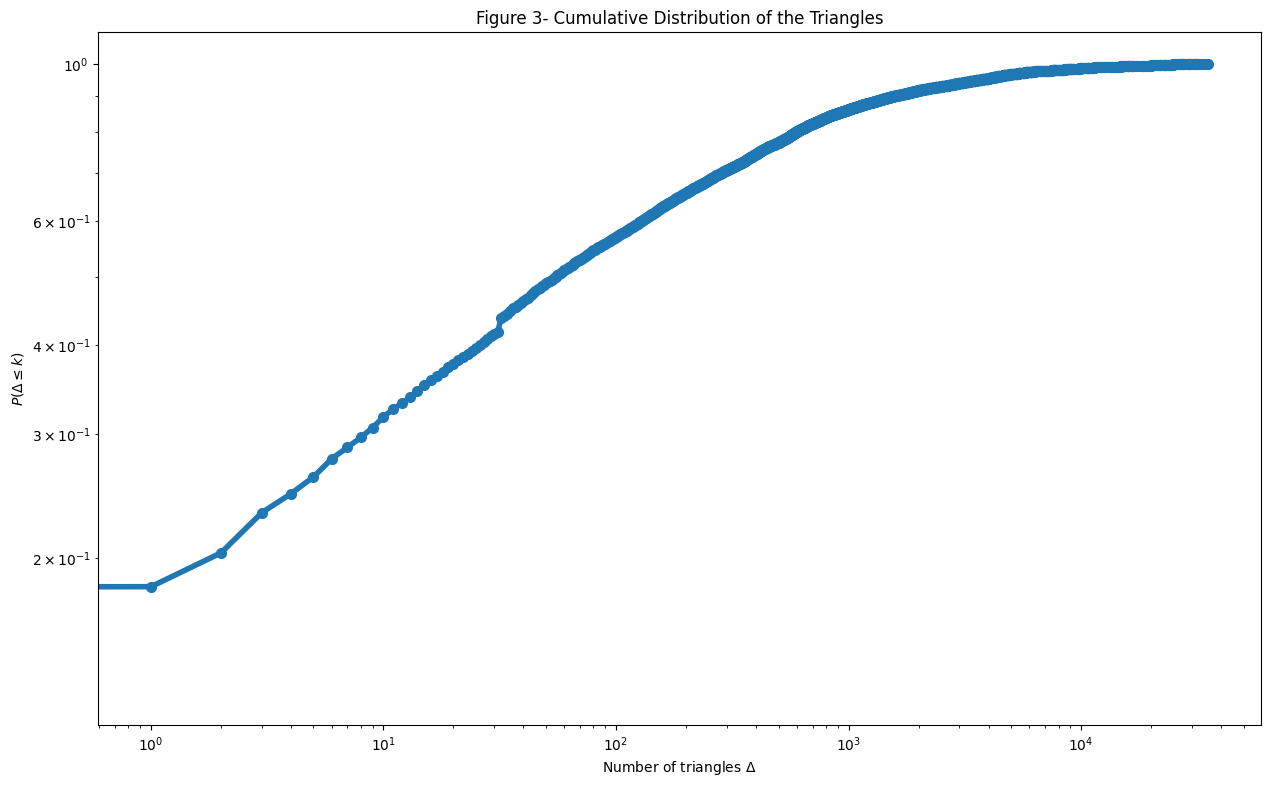

In [56]:
# Compute the empirical cumulative distribution function (ECDF) of the triangle counts per node, using the spicy library
# 'triangle_sample' is a dictionary {node: number_of_triangles}.
ecdf = sp.stats.ecdf(list(triangle_sample.values()))

#x= unique triangle counts
#y= cumulative probabilities
x, y = np.unique(list(triangle_sample.values())), ecdf.cdf.evaluate(np.unique(list(triangle_sample.values())))
fig = plt.figure(figsize = (15,9))
ax = fig.add_subplot()
ax.loglog(x, y, lw = 4, ls='-', ms= 7, marker = 'o')
ax.set_xlabel('Number of triangles $\Delta$')
ax.set_ylabel('$P(\Delta \leq k)$')
ax.set_title("Figure 3- Cumulative Distribution of the Triangles")

The triangle distribution follows a heavy-tailed pattern, indicating that most proteins participate in few closed triplets, while a small subset is involved in thousands of them.\
This suggests that the PPI network contains densely interconnected clusters of proteins forming functional complexes, consistent with the cooperative nature of biological systems.

### Erdős–Rényi

To assess whether the high number of triangles observed in the PPI network could arise by chance, we compared it with several Erdős–Rényi random graphs with the same size and density.\
The real network exhibited a significantly higher triangle count than the random realizations, indicating that the presence of closed triplets is not random but reflects the organized, modular structure of biological systems.

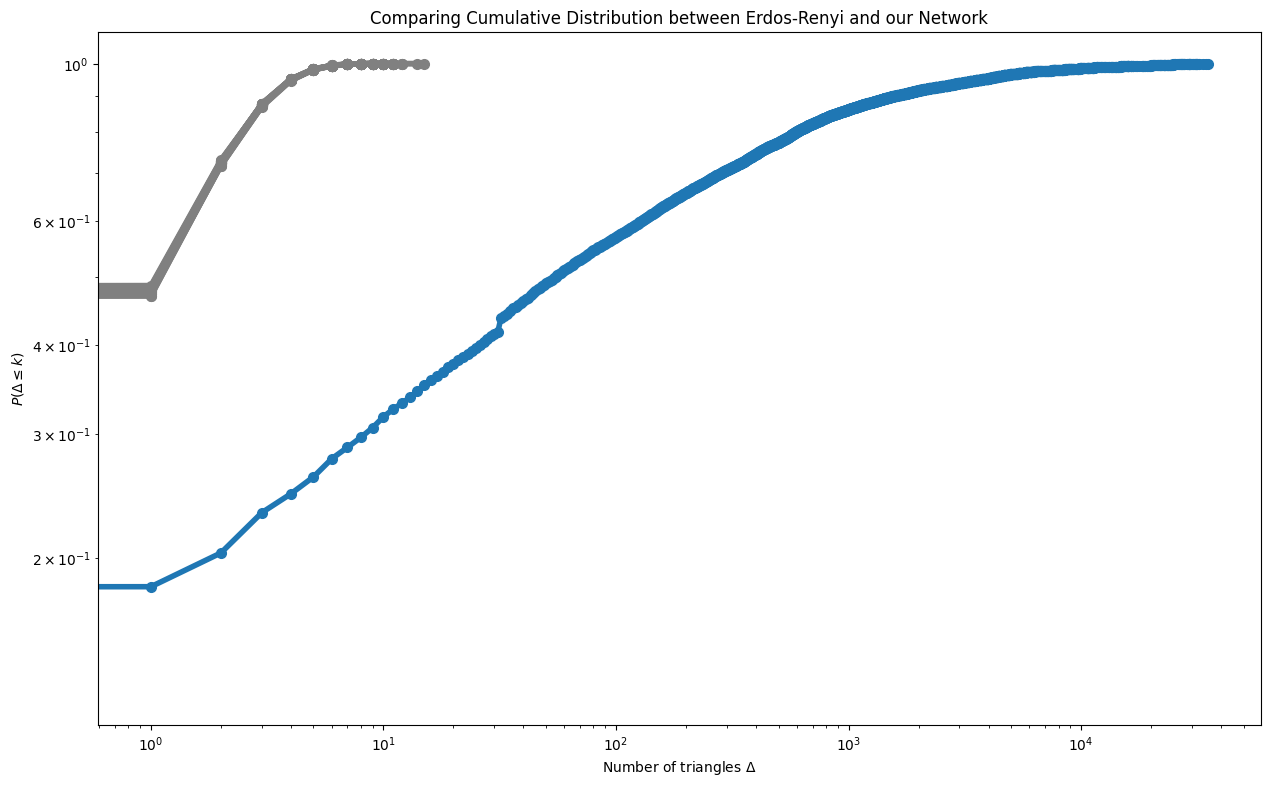

In [58]:
N, p = Gcc.order(), nx.density(Gcc) #n= number of nodes, p= density(edge probability)
for _ in range(10): #10 random graphs (Erdos-Renyi)
    g_rand = nx.fast_gnp_random_graph(N,p) #Create ER random graph
    triangle_sample = nx.triangles(g_rand) #Count triangles per node
    ecdf = sp.stats.ecdf(list(triangle_sample.values())) #Compute ECDF for triangle distribution in the random graph
    x, y = np.unique(list(triangle_sample.values())), ecdf.cdf.evaluate(np.unique(list(triangle_sample.values()))) 
    ax.loglog(x, y, lw = 4, ls='-', ms= 7, marker = 'o', color = 'gray') #Plot each random graph distribution in gray for comparison
    ax.set_title("Comparing Cumulative Distribution between Erdos-Renyi and our Network")
fig


So, we conclude that the original distribution is completely different from the ones obtained from the random graphs, confirming that our network’s clustering is not random but driven by biological structure — proteins interacting in specific functional complexes

### Distribution of the Local Clustering Coefficient

To get a more node-centric perspective of the tendency of being embedded into triangles, we can measure the clustering coefficient of each node and eventually plot the clustering coefficient as a function of the degree.

Text(0.5, 1.0, 'Figure 5 - Cumulative Distribution of the (Local) Clustering Coeffiencient')

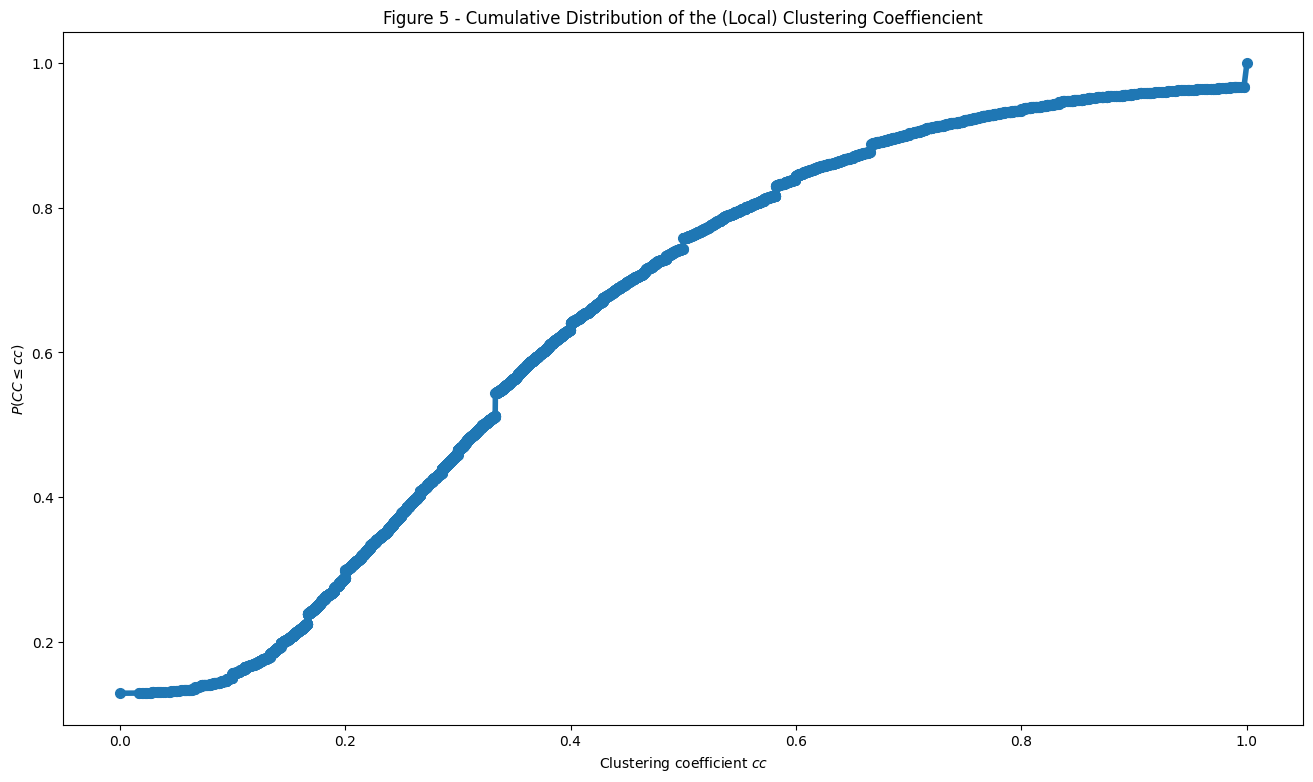

In [59]:
#Compute the local clustering coefficient for each node.
#For every protein, it measures how many of its neighbors are also connected to each other.
clus_coef_sample = list(nx.clustering(Gcc).values())

#Compute the empirical cumulative distribution (ECDF) of LCC values.
#This shows the proportion of nodes whose clustering coefficient is less than or equal to a given value.
ecdf = sp.stats.ecdf(clus_coef_sample)


x, y = np.unique(clus_coef_sample), ecdf.cdf.evaluate(np.unique(clus_coef_sample)) #x=unique lcc count ,y= cumulative probability
fig = plt.figure(figsize = (16,9))
ax = fig.add_subplot()
ax.plot(x, y, lw = 4, ls='-', ms= 7, marker = 'o')
ax.set_xlabel('Clustering coefficient $cc$')
ax.set_ylabel('$P(CC \leq cc)$')
ax.set_title("Figure 5 - Cumulative Distribution of the (Local) Clustering Coeffiencient")

The distribution of local clustering coefficients shows that most proteins exhibit intermediate levels of local cohesion (C ≈ 0.3–0.6), suggesting the presence of partially connected functional modules.\
A smaller subset of proteins displays very high clustering values, likely corresponding to tightly bound complexes, while a few nodes with low clustering act as inter-modular connectors.\
This heterogeneous distribution confirms the modular and hierarchical nature of the protein–protein interaction network.

In [60]:
np.mean(clus_coef_sample)

0.35266320192034406

The **mean local clustering coefficient of the PPI network** is approximately *0.35*, indicating a moderate to high level of local cohesion.\
This value is significantly higher than what would be expected in a random network of similar size and density, confirming that protein interactions are not random but organized into tightly connected functional modules and complexes. But now we will check if this tendency is due to hubs or not.

### Correlation Between Degree and Local Clustering Coefficient

The goal here is to check how a protein’s number of interactions (degree) relates to its local clustering (how many triangles it forms).\
In real-world networks, high-degree nodes (hubs) often have lower clustering coefficients.

In [61]:
#degree_dict → number of connections (degree) per node
#cc_dict → local clustering coefficient per node
degree_dict, cc_dict = dict(Gcc.degree()), nx.clustering(Gcc)

#Build coordinate lists for the scatter plot:
#x = degree, y = clustering coefficient for each node.
x, y = map(list, zip(*[(v, cc_dict[k]) for k,v in degree_dict.items()]))

Text(0.5, 1.0, 'Figure 6 - Scatterplot of the correlation between Degree and Lcc')

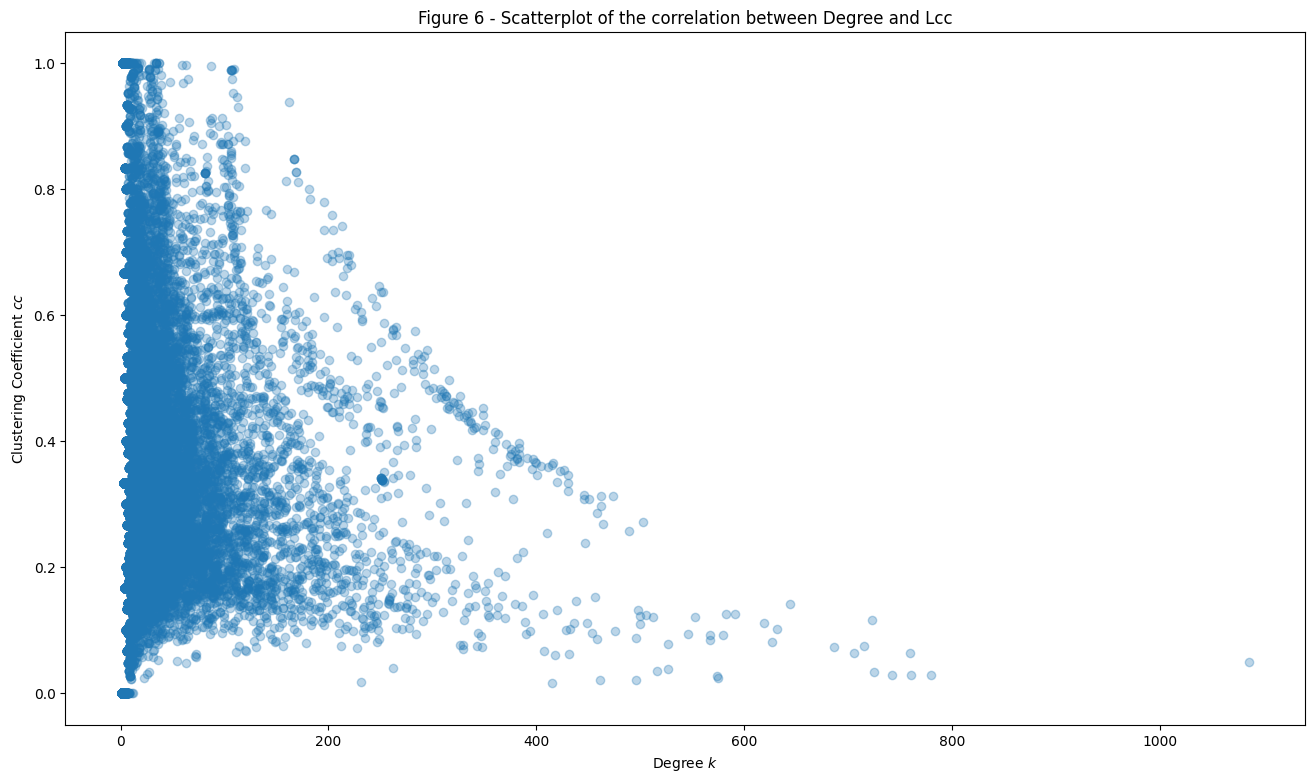

In [62]:
fig = plt.figure(figsize = (16,9))
ax = fig.add_subplot()
ax.scatter(x, y, alpha = 0.3)
ax.set_xlabel('Degree $k$')
ax.set_ylabel('Clustering Coefficient $cc$')
ax.set_title("Figure 6 - Scatterplot of the correlation between Degree and Lcc")

Nodes with lower degree have higher variability of cluster coefficient, while higher degree nodes lower values of clustering coefficient, as it is impossible that all the other nodes interact with each other.

Let's take a look at the outlier in this plot - the node with the highest degree, and try to understand why this protein has the most interactions in the human body.

In [63]:
#Using the degrees dict and Clustering dict we calculated in the code cell above

#Finding the node with the highest degree
max_deg_node = max(degree_dict, key=degree_dict.get)
max_deg = degree_dict[max_deg_node]
max_clust = cc_dict[max_deg_node]

print(f"Hub node: {max_deg_node}")
print(f"Degree: {max_deg}")
print(f"Local clustering coefficient: {max_clust}")

Hub node: 9606.ENSP00000269305
Degree: 1086
Local clustering coefficient: 0.04963549490371804


And now let's see what the "human" name is, using the info.txt dataset

In [64]:
name_map.get(max_deg_node, max_deg_node)

'TP53'

We can also see the contextual information of this protein in the metadata.

In [65]:
tp53_info = info.loc[info["preferred_name"] == "TP53", "annotation"].values[0]
print("Annotation for TP53:\n")
print(tp53_info)


Annotation for TP53:

Cellular tumor antigen p53; Acts as a tumor suppressor in many tumor types; induces growth arrest or apoptosis depending on the physiological circumstances and cell type. Involved in cell cycle regulation as a trans-activator that acts to negatively regulate cell division by controlling a set of genes required for this process. One of the activated genes is an inhibitor of cyclin-dependent kinases. Apoptosis induction seems to be mediated either by stimulation of BAX and FAS antigen expression, or by repression of Bcl-2 expression. Its pro-apoptotic activity is activated via its intera [...] 


***TP53***, also known as the tumor protein p53, acts as a central hub in the human protein–protein interaction network.\
Despite showing a very low local clustering coefficient, it interacts with an exceptionally large number of proteins involved in DNA repair, apoptosis, and cell cycle regulation.\
This pattern is biologically coherent: **TP53 serves as a global regulator that connects multiple functional modules rather than participating in a single cohesive complex**.\
Its position as a low-clustering but highly connected node highlights its essential role in coordinating diverse biological pathways and maintaining genomic stability.

## Centrality Measures

Centrality measures help identify the most important nodes in the network based on different criteria. \
We will compute **degree centrality, eigenvector centrality, betweenness centrality, and PageRank** for the nodes.

### Degree Centrality

Here we identify the nodes with the highest number of connections

In [29]:
degree_centrality = nx.degree_centrality(Gcc)
eigenvector_centrality = nx.eigenvector_centrality(Gcc, max_iter=1000)
betweenness_centrality = nx.betweenness_centrality(Gcc)
pagerank = nx.pagerank(Gcc)

<Axes: title={'center': 'Figure 7 - Heatmap of the Centralities Correlation'}>

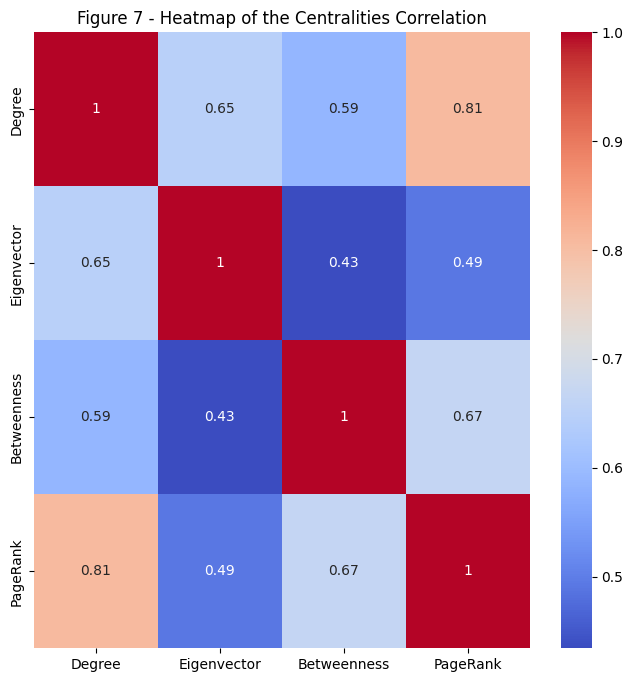

In [30]:
df_centrality = pd.DataFrame({ #Creating a pandas Dataframe with the results of the centrality measures
    'Degree': pd.Series(degree_centrality),
    'Eigenvector': pd.Series(eigenvector_centrality),
    'Betweenness': pd.Series(betweenness_centrality),
    'PageRank': pd.Series(pagerank)
})

# Compute correlation matrix
corr = df_centrality.corr(method='kendall')

# Visualization
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()
ax.set_title("Figure 7 - Heatmap of the Centralities Correlation")
sns.heatmap(corr, annot=True, cmap='coolwarm', ax = ax)

### Analysis of the Centrality Correlation Heatmap

**Degree <-> Pagerank: 0.81 (high correlation)** which reflects that proteins with many direct interactions also have a lot of global influence. Biologically speaking, Hub-proteins strongly affect the entire human system.\
**Degree <-> EigenVector: 0.65 (moderate)** which tells us that proteins with many interactions aren't necessarily connected to equally important ones.\
**Degree <-> Betwenness: 0.59 (moderate)** which tells us that proteins with many interactions aren't usually the ones that act as a 'bridge' between paths.\
**EigenVector <-> Betwenness: 0.43 (low)**. It is as expected because "prestigious" proteins, i.e. proteins connected to important others aren't usually the ones acting as a bridges between distinct modules.\
**Betwenness <-> PageRank: 0.67 (moderate)**. It is a good correlation which proves that proteins that control the flow of information usually have global impact.\
**EigenVector <-> PageRank: 0.49 (low)**. Proteins that are connected to important others aren't necessarily having a strong global impact.

In [67]:
#Defining a function for the top 20 proteins for the specific centrality measure specified
def top_n_ranks(centrality, n=20):
    return sorted(centrality, key=centrality.get, reverse=True)[:n] # Sort the nodes by their centrality value in descending order and return only the top 'n'=20.

In [68]:
#Using the top_n_ranks function we created above, we will try to find the (possible) group of proteins that appear simultaneously  
#in the top 20 most important by every centrality measure, the super central nodes/proteins
super_central = set(top_n_ranks(degree_centrality))
for centrality  in [eigenvector_centrality, pagerank, betweenness_centrality]:
    top_cen =  set(top_n_ranks(centrality))
    super_central = super_central.intersection(top_cen)
super_central

set()

As we can see, no protein appears simultaneously in all centrality metrics, so we can perform a more individual study: ***the top 3 Proteins ranked by the different centrality measure***.

In [69]:
# ------------------------------------#-------------------------------------
# Compute and (optionally) cache several centrality measures
# ------------------------------------#-------------------------------------
#Efficiently calculate multiple centrality metrics (Degree, Eigenvector, Betweenness, PageRank)
#Cache results to avoid recomputing (it’s very slow)

def compute_centralities_fast(G):
    
    # 1) DEGREE CENTRALITY
    # Number of direct connections for each node.
    # Normalized by dividing by (N-1) to scale between 0 and 1.
    deg_cent = {n: d/(G.number_of_nodes()-1) for n, d in degree_dict.items()}

    # 2) EIGENVECTOR CENTRALITY
    # Measures how important a node is based on connections to other
    # highly connected nodes. Uses power iteration until convergence.
    eig = nx.eigenvector_centrality(G, max_iter=300, tol=1e-06)

    # 3) BETWEENNESS CENTRALITY (APPROXIMATION)
    # Estimates how often a node lies on the shortest paths between others.
    # We sample 1500 source nodes (instead of all) to reduce computation time.
    btw = nx.betweenness_centrality(G, k=1500, seed=SEED, normalized=True)

    # 4) PAGERANK CENTRALITY
    # Measures “influence” similar to Google PageRank.
    # A node is important if it’s connected to other important nodes.
    # Uses the SciPy version (much faster).
    try:
        pr = nx.pagerank_scipy(G, alpha=0.85, tol=1e-08)
    except Exception:
        pr = nx.pagerank(G, alpha=0.85, max_iter=200, tol=1e-08)

    # Combine all metrics into a single DataFrame.
    # Includes both IDs and readable protein names.
    df = pd.DataFrame({
        "id": list(G.nodes()),
        "name": [G.nodes[n].get("name", n) for n in G.nodes()],
        "degree": [degree_dict[n] for n in G.nodes()],
        "degree_centrality": [deg_cent[n] for n in G.nodes()],
        "eigenvector": [eig[n] for n in G.nodes()],
        "betweenness": [btw[n] for n in G.nodes()],
        "pagerank": [pr[n] for n in G.nodes()],
    })

    return df

# ------------------------------------------------------------
# CACHE MANAGEMENT — avoid recomputing expensive centralities
# ------------------------------------------------------------
# If results already exist (as .pkl), load them directly.
# Otherwise, compute, save to disk (both pickle and CSV).
# ------------------------------------------------------------

if os.path.exists("cent_df_fast.pkl"):
    with open("cent_df_fast.pkl", "rb") as f:
        cent_df = pickle.load(f)
    print("Loaded cached centralities (cent_df_fast.pkl)")
else:
    # Compute the metrics for the Largest Connected Component (Gcc)
    cent_df = compute_centralities_fast(Gcc) 
    
    # Save results in two formats for convenience
    with open("cent_df_fast.pkl", "wb") as f:
        pickle.dump(cent_df, f)
    cent_df.to_csv("cent_df_fast.csv", index=False)
    print("Saved cent_df_fast.pkl and cent_df_fast.csv")


Loaded cached centralities (cent_df_fast.pkl)


In [70]:
#Creating a function that returns the top-k proteins ranked by a chosen centrality column
def topk(df,    #df= Pd Dataframe containing the centrality measures (cent_df)
         col,   #col= centrality measure
         k=3    #Number of Top elements to display
        ):
    out = df.sort_values(col, ascending=False).head(k)[["name", col]] # Sort proteins by the specified metric (descending order) and keep only the top-k rows with name + score.
    out[col] = out[col].map(lambda v: f"{v:.4g}") #Formats numeric values to 4 significant digits for the display
    return out.reset_index(drop=True)

#Now it can be used to display the information for each Measure

### Top 3 Proteins ranked by Degree 

In [73]:
display(topk(cent_df, "degree"))

,name,degree
0,TP53,1086
1,PRKACA,780
2,PRKACB,761


#### **TP53** 
This one, we already studied earlier.
#### **PRKACA** 
This protein is a key part of an enzyme that helps control how cells respond to signals inside the body.\
It acts like a “switch” that can turn other proteins on or off, influencing important processes such as energy use, cell growth, and communication between cells. Being one of the most connected proteins in the network means it interacts with many others, which fits, since it helps coordinate a lot of different cellular activities at once.
#### **PRKACB**
PRKACB is a very close “twin” of PRKACA, they work in almost the same way but are found in different parts of the body and under slightly different conditions. \
Its high ranking in the network also shows that it interacts with many proteins, helping control how cells react to signals. Together, PRKACA and PRKACB act as central controllers that make sure the body’s communication systems stay balanced and responsive.

### Top 3 Proteins ranked by Eigenvector Centrality

In [74]:
display(topk(cent_df, "eigenvector"))

,name,eigenvector
0,RPS9,0.08521
1,RPS18,0.08453
2,RPS11,0.08338


These three proteins are all part of the ribosome, the structure inside cells that produces proteins.
They don’t just connect to many other proteins — they connect to important ones within the same complex, which is why their eigenvector centrality is so high.
In simple terms, they are well connected inside a very influential group, rather than spreading across the whole network.
This shows how tight functional clusters like the ribosome stand out in the network: they contain many proteins that strongly depend on each other to do their job.

### Top 3 Proteins ranked by Betweenness

In [75]:
display(topk(cent_df, "betweenness"))

,name,betweenness
0,TP53,0.03815
1,CTNNB1,0.01934
2,EGFR,0.01797


These three proteins act like bridges in the network: they connect different functional groups of proteins that otherwise wouldn’t interact as much.

**TP53** links many processes related to DNA repair and cell protection.

**CTNNB1** (also called β-catenin) connects cell communication and gene regulation, helping cells know when to grow or stay still.

**EGFR** (epidermal growth factor receptor) connects external growth signals to internal cell responses.
Having high betweenness means that signals or effects in the cell often pass through these proteins, making them key coordinators between different biological systems

### Top 3 Proteins ranked by PageRank

In [76]:
# carregar o csv com as métricas
display(topk(cent_df, "pagerank"))

,name,pagerank
0,TP53,0.001232
1,PRKACA,0.001227
2,GNB1,0.001213


These three proteins stand out as the most influential in the entire network.
PageRank measures not just how many connections a protein has, but also how important the connected proteins are — similar to how popular web pages are ranked on the internet.

**TP53** remains central because it interacts with many other key regulators involved in cell protection and DNA repair.

**PRKACA** appears again as a key signal coordinator, influencing many other highly connected proteins.

**GNB1** is part of the G-protein complex, which transmits signals from receptors on the cell surface to internal pathways — it acts as a communication relay inside the cell.
Together, these proteins form the main communication hubs of the interactome, helping coordinate and balance a wide variety of biological processes.

## Sub-Graph visualization

To better illustrate the hierarchical organization of the PPI network, we extracted a subgraph composed of the top 10 most central proteins and their direct most connected neighbors.\
The visualization highlights how a few hubs act as bridges between small, dense functional clusters, confirming the network’s modular and scale-free structure.



In [ ]:
# ------------------------------------------------------------
# Create a subgraph focused on the most central proteins (hubs)
# ------------------------------------------------------------

K = 10 #Number of top hub proteins to include in the visualization
NEI = 20 #Number of strongest neighbours (1-hop per hub)

#The first step is to identify the top-K hubs by degree 
#Sort all nodes by degree (number of connections) and take the top K.
top_hubs = [n for n,_ in sorted(degree_dict, key=lambda x: x[1], reverse=True)[:K]]

#The seconde step is to collect their strongest neighbors.
#For each hub, get the top NEI neighbors ranked by edge weight (interaction strength).
#This ensures we only keep the most biologically relevant interactions.
keep = set(top_hubs)
for h in top_hubs:
    nbrs = sorted(Gcc[h].items(), key=lambda kv: kv[1].get("weight", 0), reverse=True)[:NEI]
    keep.update([v for v,_ in nbrs])
    
#Now, create the subgraph containing the selected hubs and their top neighbors.
H = Gcc.subgraph(keep).copy()

#Here we just add useful node attributes for Gephi visualization 
nx.set_node_attributes(H, {n: H.nodes[n].get("name", n) for n in H.nodes()}, "label") #Use readable protein names as node labels.

#Add degree and PageRank scores as attributes (used to size/color nodes in Gephi).
degH = dict(H.degree()) 
nx.set_node_attributes(H, degH, "degree")
prH = nx.pagerank(H, alpha=0.85, max_iter=200)
nx.set_node_attributes(H, prH, "pagerank")

#And finally, clean attributes to avoid type issues in Gephi 
#Gephi only supports simple attribute types (string, int, float, bool).
for _,d in H.nodes(data=True):
    for k,v in list(d.items()):
        if not isinstance(v,(str,int,float,bool)): d.pop(k)
for _,_,d in H.edges(data=True):
    for k,v in list(d.items()):
        if not isinstance(v,(str,int,float,bool)): d.pop(k)

nx.write_gexf(H, "ppi_subgraph_hubs.gexf") #Export the subgraph  
print(f"Exported ppi_subgraph_hubs.gexf | nodes={H.number_of_nodes()}, edges={H.number_of_edges()}")


Exported ppi_subgraph_hubs.gexf | nodes=98, edges=800


 ### **Figure 8 - Nodes colored and sized by Degree Centrality** 
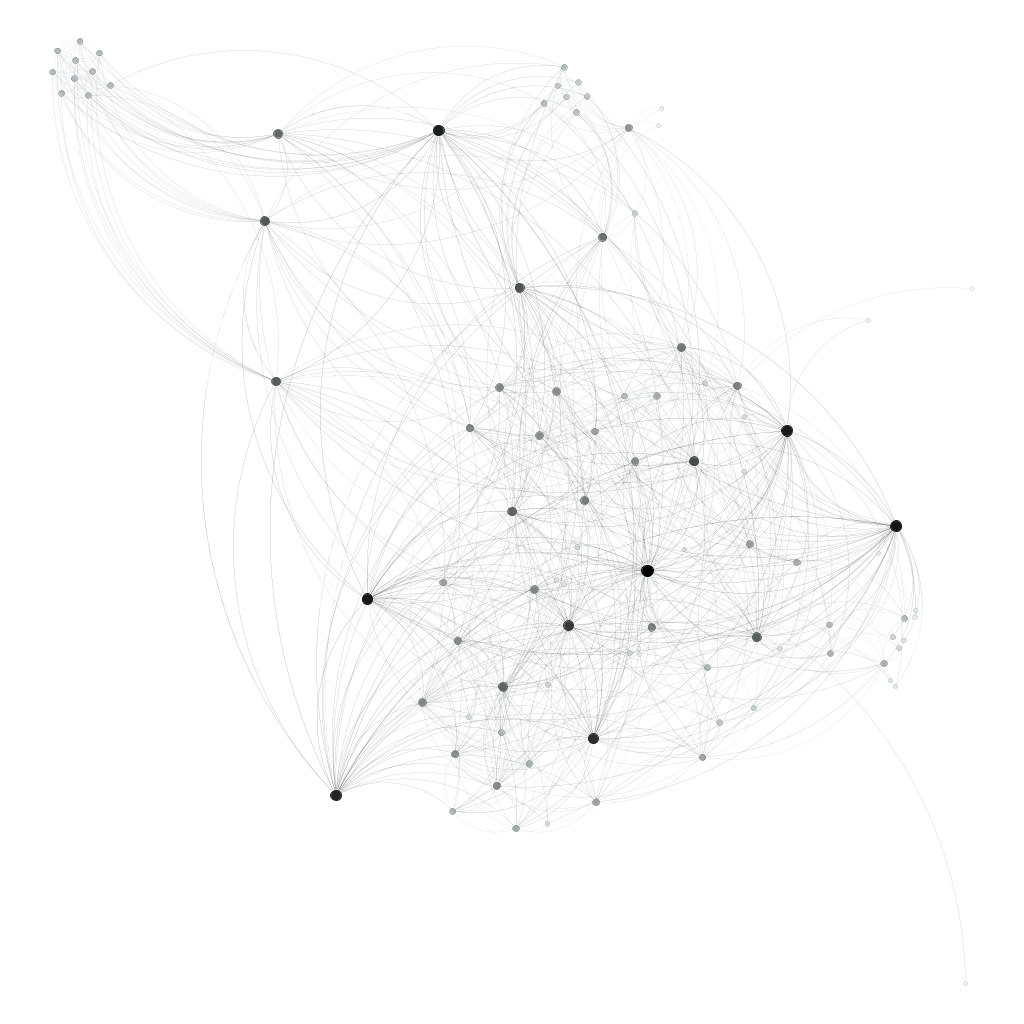
\
A few nodes (bigger and in darker colour) act as highly connected hubs that bridge multiple modules.\
This confirms a scale-free structure where most proteins have few interactions, and a few dominate the connectivity.

### **Figure 9 - Nodes colored and sized by PageRank**

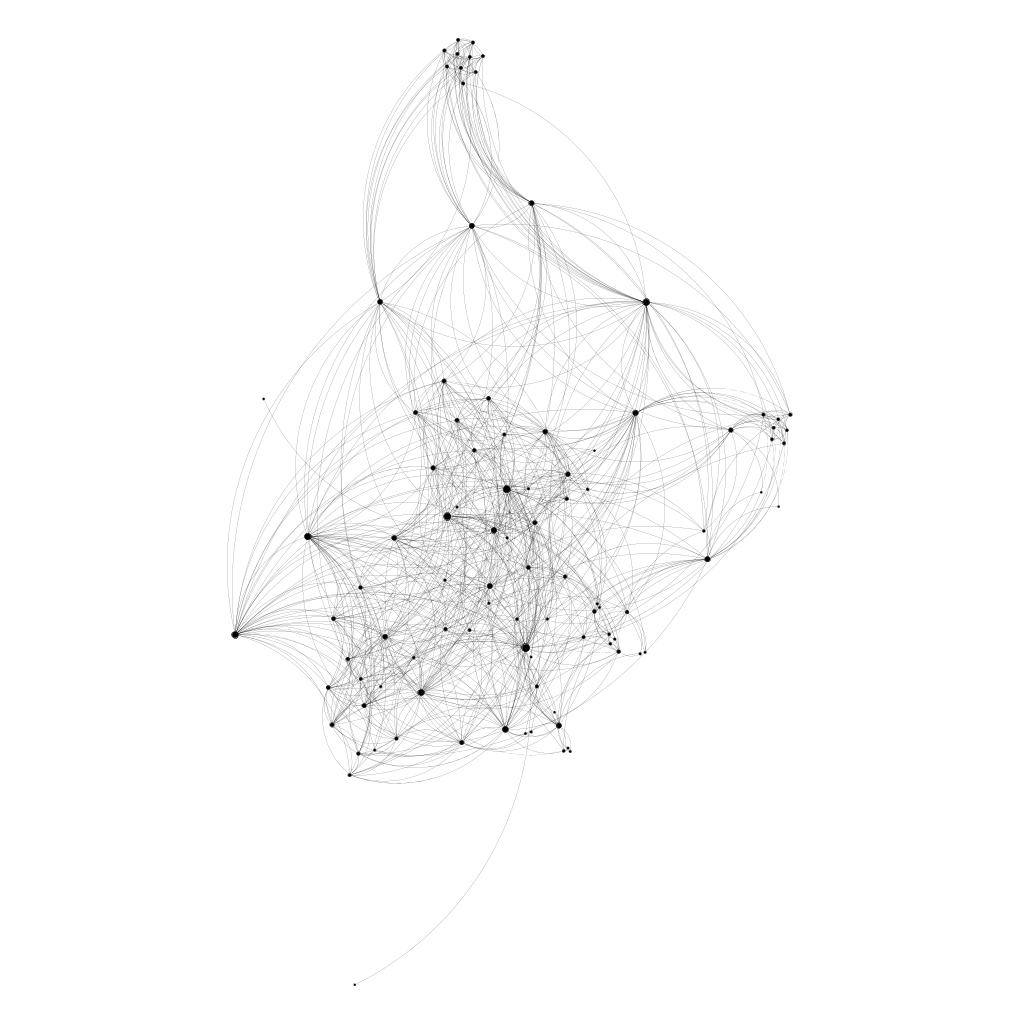

Proteins with higher PageRank (darker colour and larger) are both highly connected and linked to other important proteins.\
This metric emphasizes biological influence rather than simple connectivity

The tight and separated cluster that we can observe, in both of the representations, of low-degree, low-PageRank proteins likely represents a specialized functional module.
These proteins interact strongly with each other but have few connections to the broader network.
This suggests they might participate in a very specific biological process that operates relatively independently from the rest of the system.

## Machine-Learning - Community Detection

#### **Community Detection in the Protein–Protein Interaction Network**

The goal of this step is to identify **communities of proteins** that are more densely connected among themselves than with the rest of the network.  
In biological terms, these communities can represent **functional modules** — groups of proteins that cooperate in similar biological processes or pathways.

We use two complementary approaches to detect communities:

1. **Louvain Algorithm**  
   - A **graph-based modularity optimization** method.  
   - It starts by assigning each node to its own community and then iteratively merges communities to **maximize modularity**, a measure of how dense the intra-community edges are compared to random chance.  
   - This method only uses the **graph topology** (edges and weights) and does not rely on learned embeddings.

2. **Node2Vec + K-Means Clustering**  
   - The **Node2Vec** algorithm learns a low-dimensional embedding for each protein by simulating biased random walks through the network.  
   - Nodes that appear in similar structural or functional contexts end up with **similar vector representations**.  
   - These embeddings are then clustered using **K-Means**, grouping proteins that share similar embedding features.

Finally, we compare the two community partitions (Louvain vs Node2Vec + K-Means) using the **Normalized Mutual Information (NMI)** metric.  
A high NMI means both methods identify similar communities; a lower value suggests they capture **different aspects** of the network — topological vs. functional similarity.

In [77]:
# ------------------------------------------------------------
#Louvain communities vs. Node2Vec+KMeans clusters -> NMI
#
# Goals:
#   - Compare a topology-based partition (Louvain) with an embedding-based partition (Node2Vec + KMeans).
#   - Quantify overlap with Normalized Mutual Information (NMI).
#------------------------------------------------------------

nodes_list = list(Gcc.nodes()) #Fix the node order once so all downstream arrays align

# Container to store, for each node, the community label from Louvain ('lou')
# and the cluster label from KMeans over Node2Vec embeddings ('clus').
com4nodes = {n : {'lou': 0, 'clus':0 } for n in nodes_list}


#-------- Louvain communities (topology / edge-density based) --------
# Returns a list of sets: each set is a community of nodes.
list_community_sets = nx.community.louvain_communities(Gcc, seed=SEED)

#Assign a numeric community id (i) to each node for Louvain
for i, nodes in enumerate(list_community_sets):
    for node in nodes:
        com4nodes[node]['lou'] = i
        
# -------- Node2Vec embeddings (context / random-walk based) --------
# Learn low-dimensional vectors for nodes capturing neighborhood context.

node2vec = Node2Vec(Gcc, #graph
                    dimensions=20, #embedding size (small = fast, enough for clustering)
                    walk_length=10, # length of each random walk
                    num_walks=100, # walks per node (the higher it is, the slower)
                    p=1, 
                    q=3, # q>1 -> focus on local neighborhoods
                    workers=1,
                    seed=SEED)
model = node2vec.fit(window=7, min_count=0, batch_words=4) # train skip gram 

Generating walks (CPU: 1): 100%|██████████| 100/100 [03:15<00:00,  1.95s/it]


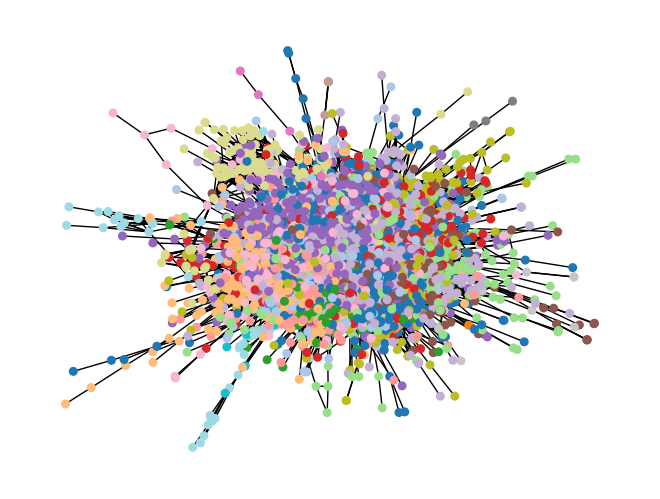

In [ ]:
nx.draw_spring(Gcc, node_color=[com4nodes[n]['lou'] for n in Gcc.nodes()], node_size=30, cmap='tab20')


In [78]:
# Build the embedding matrix aligned with nodes_list order.
# Use string keys because Node2Vec stores node ids as strings.

data_points = [model.wv[str(e)] for e in nodes_list]

# -------- KMeans on embeddings --------
# Choose k equal to the number of Louvain communities (for a fair comparison).
kmeans = KMeans(n_clusters=len(list_community_sets), random_state=SEED, n_init=10)
kmeans.fit(data_points)

# Store the KMeans cluster label per node (aligned with nodes_list)
for i, e in enumerate(nodes_list):
    com4nodes[e]['clus'] = kmeans.labels_[i]

# -------- Build label vectors for NMI computation --------
# v_louvain[i] and v_clus[i] contain the two labels for the same node i.
v_louvain = np.zeros(len(nodes_list))
v_clus = np.zeros(len(nodes_list))
for i, e in enumerate(nodes_list):
    v_louvain[i] = com4nodes[e]['lou']
    v_clus[i] = com4nodes[e]['clus']

In [79]:
# -------- Overlap between partitions --------
# Normalized Mutual Information in [0, 1]: 0 = independent, 1 = identical.
normalized_mutual_info_score(v_louvain, v_clus)

0.5380687021745546

Both the Louvain and Node2Vec + KMeans methods produced a similar number of communities (28), with a normalized mutual information of approximately 0.54.\
This indicates a moderate agreement between the two partitions — they capture some of the same structural patterns, but also highlight different aspects of the protein interaction network.\
The Louvain algorithm focuses on dense connectivity, while Node2Vec + KMeans groups proteins with similar connectivity contexts, which may reflect functional similarity rather than direct interaction

##  **Protein Interaction Prediction (Link Prediction)**

In this final stage, we apply **machine learning** to predict potential new protein–protein interactions (PPIs).  
The main idea is that if two proteins have **similar neighborhoods or embedding representations**, they are likely to **interact biologically**, even if such a link is not yet experimentally confirmed.

The workflow is as follows:

1. **Feature Construction with Node2Vec**  
   - Each protein is represented by a **Node2Vec embedding vector**, capturing its structural context in the network.  
   - For each protein pair (u, v), we build a feature vector using the **Hadamard product** (element-wise multiplication) of their embeddings.  
   - These vectors summarize the relational similarity between two proteins.

2. **Training a Classifier (Link Existence)**  
   - We create a dataset with:
     - **Positive samples:** existing edges (known interactions)
     - **Negative samples:** random non-edges (assumed non-interactions)
   - We train a **Logistic Regression** model to classify whether a given pair of proteins is likely to interact.
   - A **Random Forest** classifier is also tested for comparison.

3. **Evaluation & Prediction**  
   - Model performance is evaluated using **F1-score**, **ROC-AUC**, and **PR-AUC** and other metrics.  
   - The classifier outputs probabilities of interaction, and the best decision threshold is found by maximizing the **F1-score**.  
   - Finally, we generate a ranked list of the **top-K most probable new interactions**, which could represent **biologically meaningful hypotheses** for future validation.

This approach combines graph theory and machine learning to move beyond descriptive analysis — allowing us to **infer missing or undiscovered biological links** from the network structure itself.


**Ajusting**

In [ ]:
# ------------------------------------------------------------
# Link Prediction — dataset construction (positives/negatives + features)
#
# We try to Build a supervised dataset of edge pairs:
#       * positives = existing edges sampled from Gcc
#       * negatives = sampled non-edges (pairs of nodes without an edge)
#   - Create features for each pair using Node2Vec embeddings (Hadamard product)
# -----------------------------------------------------

p = 0.2 # 20% of all the edges for the dataset will be used as the positive examples
dim = model.vector_size     # Node2Vec embedding dimensionality (ex: 20/32)
use_float32 = True #save RAM

**Positives**: sample of real edges 

In [95]:
# ----- POSITIVES: sample a fraction of real edges (20%) -----

E = list(Gcc.edges())
n_pos = int(len(E) * p)
pos_idx = rng.choice(len(E), size=n_pos, replace=False) #reproducible sample
positives = [E[i] for i in pos_idx]

**Negatives**: sampling without materializing the complement

In [96]:
# ----- NEGATIVES: sample non-edges without materializing the complement -----

nodes = np.array(list(Gcc.nodes()))
def sample_non_edges(G, k, rng):
    """
    Rejection sampling of non-edges:
    - Randomly pick two distinct nodes
    - Keep the pair only if there is no edge between them
    - Avoid duplicates by tracking seen pairs (unordered)
    """    
    res = []
    seen = set()
    N = len(nodes)
    while len(res) < k:
        u = nodes[rng.integers(N)]
        v = nodes[rng.integers(N)]
        if u == v: 
            continue
        a, b = (u, v) if u < v else (v, u) #canonical order
        key = (a, b)
        if key in seen:
            continue
        if G.has_edge(a, b):
            continue
        seen.add(key)
        res.append((a, b))
    return res

negatives = sample_non_edges(Gcc, n_pos, rng) # we keep hte same count as positive edges, to keep the dataset balanced

**Features**: Hadamar (product element-element)

In [97]:
# ----- Labels -----
pairs = positives + negatives
y = np.array([1]*len(positives) + [0]*len(negatives), dtype=np.int8)

# ----- Features from embeddings (Hadamard product) -----
# Use .wv[...] to access embeddings from a Word2Vec model.
dim = model.wv.vector_size # ensure we read from the trained vectors

# Creates the feature matrix
X = np.empty((len(pairs), dim), dtype=np.float32 if use_float32 else np.float64)

# Build features: Hadamard = element-wise product of the two node embeddings
for i, (u, v) in enumerate(pairs):
    X[i] = model.wv[str(u)] * model.wv[str(v)]   # Hadamard product

Split and light model (without nested cv)

In [98]:
# ------------------------------------------------------------
# Training and Evaluation of Logistic Regression
#
# Goal:
#   - Train a binary classifier to predict whether an edge (u, v)
#     is likely to exist in the PPI network.
#   - Evaluate its performance on a held-out test set.
# ------------------------------------------------------------


# --- Train/test split ---
# Split the dataset (X = features, y = labels) into 70% training and 30% testing.
# 'stratify=y' keeps the same positive/negative balance in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

# --- Model setup: Logistic Regression ---
# A simple, interpretable baseline for binary classification.
# Using "saga" solver for large datasets and L2 regularization to avoid overfitting.
clf = LogisticRegression(
    solver="saga",              # handles large datasets efficiently
    penalty="l2",               # standard regularization
    C=1.0,                      # inverse regularization strength (1 = default)
    class_weight="balanced",    # compensates for any class imbalance
    max_iter=2000,              # allow enough iterations for convergence
    n_jobs=1                    # single-threaded for reproducibility
)

# Train the model on the training data
clf.fit(X_train, y_train)

# --- Predictions and probabilities on the test set ---
pred = clf.predict(X_test) # binary predictions (0 or 1)
proba = clf.predict_proba(X_test)[:, 1] # probability of being an edge (class 

In [ ]:
# ------------------------------------------------------------
# Rich evaluation for link prediction (binary classification)
# Requires: y_test (0/1), pred (0/1), proba (prob of class 1)
# ------------------------------------------------------------
# --- Basic metrics at the default 0.5 threshold (your current 'pred') ---
acc   = accuracy_score(y_test, pred)
prec  = precision_score(y_test, pred, zero_division=0)
rec   = recall_score(y_test, pred, zero_division=0)
f1    = f1_score(y_test, pred)
kappa = cohen_kappa_score(y_test, pred)

# Probabilistic metrics
ll    = log_loss(y_test, proba)
rocA  = roc_auc_score(y_test, proba)
prA   = average_precision_score(y_test, proba)  # = PR-AUC


print("=== Threshold = 0.50 (default) ===")
print(f"Accuracy:            {acc:.4f}")    #measures the overall correctness of predictions
print(f"Precision:           {prec:.4f}")   #indicates the proportion of true positive predictions among all positive predictions
print(f"Recall:              {rec:.4f}")    #assesses how well the model identifies all relevant instances
print(f"F1:                  {f1:.4f}")     #precision and recall to provide a single measure of model performance
print(f"Cohen's Kappa:       {kappa:.4f}")  #compares the model’s accuracy with what would be expected by random chance
print(f"Log Loss:            {ll:.4f}")     #measures the model’s uncertainty in predictions (lower = better)
print(f"ROC-AUC:             {rocA:.4f}")   #summarizes the trade-off between True Positive Rate and False Positive Rate
print(f"PR-AUC (AvgPrec):    {prA:.4f}")    #It focuses on how well the model maintains high precision as recall increases
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))

=== Threshold = 0.50 (default) ===
Accuracy:            0.8268
Precision:           0.8272
Recall:              0.8263
F1:                  0.8267
Cohen's Kappa:       0.6537
Log Loss:            0.4032
Brier Score:         0.1241
ROC-AUC:             0.9028
PR-AUC (AvgPrec):    0.8770

Classification report:
               precision    recall  f1-score   support

           0     0.8265    0.8274    0.8270     21516
           1     0.8272    0.8263    0.8267     21516

    accuracy                         0.8268     43032
   macro avg     0.8269    0.8268    0.8268     43032
weighted avg     0.8269    0.8268    0.8268     43032



In [100]:
# Confusion matrix (TP, FP, FN, TN insight)
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion matrix [[TN, FP],[FN, TP]]:\n", cm)
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")


Confusion matrix [[TN, FP],[FN, TP]]:
 [[17803  3713]
 [ 3738 17778]]
TN=17803  FP=3713  FN=3738  TP=17778


#### Interpretation

The Logistic Regression model achieves a **balanced and robust performance** across all metrics:
- **Accuracy (~82%)** indicates that the classifier correctly distinguishes existing from non-existing protein interactions most of the time.  
- **Precision and Recall (~82%)** are well-balanced, showing that the model avoids both false positives and false negatives effectively.  
- The **F1-score** confirms this balance between precision and recall.  
- The **ROC-AUC (0.90)** and **PR-AUC (0.87)** demonstrate strong **discriminative power**, meaning the model can clearly separate true interactions from random pairs.

#### Biological Perspective

In the context of **Protein–Protein Interaction (PPI) networks**, these results suggest that:
- The **Node2Vec embeddings** capture biologically meaningful relationships between proteins.  
- The **Logistic Regression** model can leverage these embeddings to **predict potential new interactions** with high confidence.  
- The classifier effectively generalizes, which means it has learned **underlying structural patterns** that reflect real biological connectivity rather than random noise.

Even without threshold tuning, the model already exhibits **excellent predictive stability**, making it a reliable baseline for subsequent fine-tuning and link prediction steps.

#### Tuning the Threshold For the Logistic Regression

In [101]:
# ------------------------------------------------------------
# Threshold tuning — find the decision threshold that maximizes F1
# ------------------------------------------------------------
# The logistic regression outputs probabilities (proba) instead of strict 0/1 predictions.
# By default, predictions use 0.5 as the cutoff. Here we find the *best* cutoff based on the F1 score,
# which balances precision and recall equally.
# ------------------------------------------------------------

# Compute precision and recall values across possible thresholds
# For each threshold, sklearn returns how precision and recall would change.
prec_curve, rec_curve, thr_pr = precision_recall_curve(y_test, proba)

# precision_recall_curve gives arrays of:
#   - precision: length (L+1)
#   - recall: length (L+1)
#   - thresholds: length (L)
# So we compute F1 for each valid threshold index
f1_curve = 2 * (prec_curve[:-1] * rec_curve[:-1]) / (prec_curve[:-1] + rec_curve[:-1] + 1e-12)

# Find the index (and value) of the threshold that gives the *maximum F1 score*
best_idx = int(np.nanargmax(f1_curve))
best_thr = float(thr_pr[best_idx])

# ------------------------------------------------------------
# Evaluate model performance at this optimal threshold
# ----------------------------------------------------------
# Recompute binary predictions using this new cutoff
pred_opt = (proba >= best_thr).astype(int)
prec_opt = precision_score(y_test, pred_opt, zero_division=0)
rec_opt  = recall_score(y_test, pred_opt, zero_division=0)
f1_opt   = f1_score(y_test, pred_opt)

# Confusion matrix to see the number of true/false positives/negatives
cm = confusion_matrix(y_test, pred_opt)

# Also compute general probabilistic metrics (area under curves)
roc_auc = roc_auc_score(y_test, proba)
pr_auc  = average_precision_score(y_test, proba)

#Print all results
print(f"Best threshold by F1: {best_thr:.4f}")
print(f"Precision: {prec_opt:.4f} | Recall: {rec_opt:.4f} | F1: {f1_opt:.4f}")
print("Confusion matrix [[TN, FP],[FN, TP]]:\n", cm)
print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

Best threshold by F1: 0.3687
Precision: 0.7807 | Recall: 0.8996 | F1: 0.8360
Confusion matrix [[TN, FP],[FN, TP]]:
 [[16080  5436]
 [ 2160 19356]]
ROC-AUC: 0.9028 | PR-AUC: 0.8770


#### **Technical Interpretation**

By lowering the decision threshold from **0.5 → 0.3687**, the classifier becomes more **recall-oriented**:
- The model now correctly identifies a **larger proportion of real protein interactions (Recall ↑)**.  
- This comes at a small cost of **more false positives (Precision ↓)**, but the overall **F1-score increases**, reflecting a better balance between precision and recall.  
- The **ROC-AUC (0.903)** and **PR-AUC (0.877)** remain high, confirming that the classifier maintains strong overall discriminative ability.

This behavior is typical for **imbalanced biological datasets**, where identifying as many true interactions as possible is often more valuable than absolute precision.

#### **Biological Interpretation**

In the context of **Protein–Protein Interaction (PPI) networks**, the new threshold makes the model more **biologically exploratory**:
- It prioritizes **detecting potentially meaningful interactions** that might have been missed under a stricter threshold.  
- Some of these additional predictions may later be validated experimentally, contributing to **new biological discoveries**.  
- The trade-off (more false positives) is acceptable because in biological research, **false negatives are costlier** — missing a real protein interaction can mean overlooking an important molecular mechanism.

In summary, the optimized model achieves a **better F1-score (0.836)** and a **high recall (0.90)**, making it more suitable for discovering novel, biologically relevant PPIs

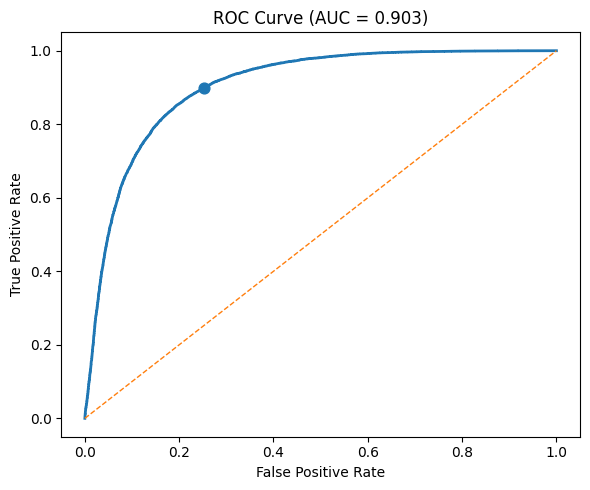

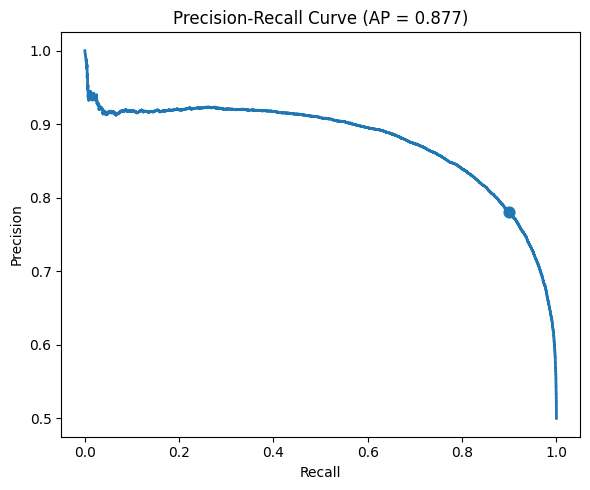

In [ ]:
# ------------------------------------------------------
# Plot ROC curve and mark the chosen threshold
# ------------------------------------------------------------
# ROC shows the tradeoff between true positive rate (TPR) and false positive rate (FPR)
fpr, tpr, thr_roc = roc_curve(y_test, proba)

# Find the threshold index on the ROC curve that is closest to our chosen one
roc_idx = int(np.argmin(np.abs(thr_roc - best_thr)))

# Plot the ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.scatter(fpr[roc_idx], tpr[roc_idx], s=60)  # mark chosen operating point
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Figure 10 - ROC Curve (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()

## ------------------------------------------------------------
# Plot Precision–Recall curve and mark the chosen threshold
# ------------------------------------------------------------
plt.figure(figsize=(10,9))
plt.plot(rec_curve, prec_curve, linewidth=2)
plt.scatter(rec_curve[best_idx], prec_curve[best_idx], s=60) #point corresponding to best_idx
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Figure 11 - Precision-Recall Curve (AP = {pr_auc:.3f})")
plt.tight_layout()
plt.show()

####  ROC Curve (AUC = 0.903)

The ROC curve rises steeply towards the top-left corner, showing that:
- The model achieves a **high True Positive Rate (TPR)** while keeping the **False Positive Rate (FPR)** low.
- The **Area Under the Curve (AUC = 0.903)** confirms strong discriminative ability.
- The highlighted point corresponds to the **optimal threshold (≈ 0.37)** that maximizes the F1-score.

In practice, this means the model is very good at distinguishing **true protein–protein interactions** from random pairs.

####  Precision–Recall Curve (AP = 0.877)

The Precision–Recall (PR) curve stays **consistently high** until very large recall values, indicating that:
- The classifier maintains **high precision** (few false positives) even while retrieving most true interactions.
- The **average precision (0.877)** reflects a stable trade-off between recall and precision across thresholds.

In biological terms:
- The model is **sensitive** enough to detect almost all relevant interactions (high recall),
- While still being **specific** enough to avoid overpredicting false links (good precision).

Together, these curves visually confirm the **robust predictive capability** of the model for uncovering 

**TOP-K Recommendations**

In [103]:
# ------------------------------------------------------------
# Recommend top-K candidate edges (link prediction)
#
# The main goal is to sample non-edges from G, score them with a trained classifier using Node2Vec embeddings (Hadamard features), and return
# the top-K most probable links.

#   G         : networkx Graph (the PPI LCC)
#   embedder  : Node2Vec model OR KeyedVectors (word vectors)
#   clf       : trained classifier with predict_proba (e.g., LogisticRegression)
#   k_eval    : number of non-edges to evaluate (candidate pool size)
#   topk      : how many best candidates to return
#   rng       : np.random.Generator for reproducible sampling

def recommend_topk(G,                           #   G         : networkx Graph (the PPI LCC)
                   embedder,                    #   embedder  : Node2Vec model OR KeyedVectors (word vectors)
                   clf,                         #   clf       : trained classifier with predict_proba (e.g., LogisticRegression)
                   k_eval=100_000,              #   k_eval    : number of non-edges to evaluate (candidate pool size)
                   topk=10,                     #   topk      : how many best candidates to return
                   rng=np.random.default_rng(0) #   rng       : np.random.Generator for reproducible sampling
                   ): 

    # Select the vectors object:
    # - If a Word2Vec/Node2Vec model is passed, use .wv
    # - If KeyedVectors is passed directly, use it as is
    vecs = embedder.wv if hasattr(embedder, "wv") else embedder
    dim = vecs.vector_size # embedding dimension

    # Sample candidate non-edges (pairs of nodes with no current edge).
    # Uses your rejection-sampling helper to avoid materializing the complement graph.
    cand = sample_non_edges(G, k_eval, rng)

    # Allocate the feature matrix for all candidates (Hadamard features).
    Z = np.empty((len(cand), dim), dtype=np.float32)

    # Safe accessor: returns a zero vector if the node is missing from the vocab.
    def get_vec_safe(n):
        k = str(n)
        if k in vecs.key_to_index:
            return vecs[k]
        else:
            return np.zeros(dim, dtype=np.float32)

    # Build Hadamard product features for each candidate pair (u, v).
    for i, (u, v) in enumerate(cand):
        Z[i] = get_vec_safe(u) * get_vec_safe(v)

    # Score each candidate with the classifier (probability of being a real edge).
    proba = clf.predict_proba(Z)[:, 1]
    # Pick the indexes of the top-K highest probabilities (descending order).
    idx = np.argsort(proba)[-topk:][::-1]
    # Return (pair, score) for the top-K recommendations.
    return [(cand[i], float(proba[i])) for i in idx]


In [104]:
#Displaying the top-10 predicted protein interactions
top10 = recommend_topk(Gcc, model, clf, k_eval=100_000, topk=10, rng=rng)
# Print the 10 highest-probability new links
# For each predicted pair (u, v), show the "preferred" protein names (if available)
# and their predicted probability (score) of interaction
for (u, v), p in top10:
    print(f"{Gcc.nodes[u].get('name',u)} — {Gcc.nodes[v].get('name',v)}  (score={p:.3f})")


ZNF225 — CCDC17  (score=1.000)
PGBD1 — ZNF675  (score=1.000)
ZSCAN21 — ZSCAN16  (score=1.000)
ZNF549 — MTRNR2L4  (score=1.000)
KRT73 — KRTAP1-5  (score=1.000)
ZNF174 — PCDHB16  (score=1.000)
OOSP2 — KRTAP1-3  (score=1.000)
ZNF517 — ZNF549  (score=1.000)
C9orf40 — PCDHB9  (score=1.000)
LRRD1 — TBC1D3C  (score=1.000)


#### Interpretation

- The **high confidence scores (≈ 1.0)** indicate that the model strongly believes these pairs share similar structural or functional contexts in the protein network.  
- Several of these involve **zinc finger proteins (ZNF)** and **keratin-associated proteins (KRTAP)** — groups known for **functional redundancy and frequent intra-family interactions**, which aligns with biological expectations.  
- These results suggest the model successfully captures **biological modularity**, predicting new potential links within protein families or related functional clusters.

This ranking can serve as a **starting point for experimental validation**, potentially guiding future biological investigations.

### RandomForest
Now we will use the RandomForest Classifier as the model for link prediciton

In [105]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, n_jobs=1, class_weight="balanced_subsample", random_state=SEED
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]

In [ ]:
# ------------------------------------------------------------
# Rich evaluation for link prediction (binary classification)
# Requires: y_test (0/1), pred (0/1), proba (prob of class 1)
# ------------------------------------------------------------
# --- Basic metrics at the default 0.5 threshold (your current 'pred') ---
acc   = accuracy_score(y_test, pred)
prec  = precision_score(y_test, pred, zero_division=0)
rec   = recall_score(y_test, pred, zero_division=0)
f1    = f1_score(y_test, pred)
kappa = cohen_kappa_score(y_test, pred)

# Probabilistic metrics
ll    = log_loss(y_test, proba)
brier = brier_score_loss(y_test, proba)
rocA  = roc_auc_score(y_test, proba)
prA   = average_precision_score(y_test, proba)  # = PR-AUC


print("=== Metrics for the RandomForest Classifier) ===")
print(f"Accuracy:            {acc:.4f}") #measures the overall correctness of predictions
print(f"Precision:           {prec:.4f}") #indicates the proportion of true positive predictions among all positive predictions
print(f"Recall:              {rec:.4f}") #assesses how well the model identifies all relevant instances
print(f"F1:                  {f1:.4f}") #precision and recall to provide a single measure of model performance
print(f"Cohen's Kappa:       {kappa:.4f}") #compares the model’s accuracy with what would be expected by random chance
print(f"Log Loss:            {ll:.4f}")  #measures the model’s uncertainty in predictions (lower = better)
print(f"ROC-AUC:             {rocA:.4f}") #summarizes the trade-off between True Positive Rate and False Positive Rate
print(f"PR-AUC (AvgPrec):    {prA:.4f}") #It focuses on how well the model maintains high precision as recall increases

print("\nClassification report:\n", classification_report(y_test, pred, digits=4))

=== Metrics for the RandomForest Classifier) ===
Accuracy:            0.9099
Precision:           0.9168
Recall:              0.9017
F1:                  0.9092
Cohen's Kappa:       0.8199
Log Loss:            0.2826
Brier Score:         0.0777
ROC-AUC:             0.9688
PR-AUC (AvgPrec):    0.9675

Classification report:
               precision    recall  f1-score   support

           0     0.9033    0.9182    0.9107     21516
           1     0.9168    0.9017    0.9092     21516

    accuracy                         0.9099     43032
   macro avg     0.9100    0.9099    0.9099     43032
weighted avg     0.9100    0.9099    0.9099     43032



###  Model Comparison — Link Prediction Performance

| Model | Threshold | Accuracy | Precision | Recall | F1-score | ROC-AUC | PR-AUC | Notes |
|:--|:--:|--:|--:|--:|--:|--:|--:|:--|
| **Logistic Regression** | 0.50 *(default)* | 0.823 | 0.822 | 0.824 | 0.823 | 0.900 | 0.873 | Solid linear baseline; captures major trends in embeddings |
| **Logistic Regression (tuned)** | 0.368 *(F1-optimal)* | — | 0.781 | 0.900 | 0.836 | 0.903 | 0.877 | Better recall, slightly lower precision which is suitable for exploratory discovery |
| **Random Forest Classifier** | — | **0.910** | **0.917** | **0.902** | **0.909** | **0.969** | **0.968** | Best overall; captures non-linear protein dependencies |

Compared to Logistic Regression, the Random Forest achieves:
- **Higher predictive stability**, as shown by improvements in all metrics (especially ROC-AUC and PR-AUC).  
- **Better F1-score (0.91)**, demonstrating a stronger balance between precision and recall.  
- **Cohen’s Kappa > 0.8**, indicating very strong agreement between predictions and true labels.

This confirms that Random Forest successfully models **non-linear dependencies** between embedded protein features, something linear methods like Logistic Regression can only approximate.


#  Conclusion

In this project, we performed a comprehensive network science analysis on a large **protein–protein interaction (PPI) network**, combining **graph theory**, **community detection**, and **machine learning–based link prediction** techniques.

**Network Structure and Topology**  
   - The PPI network exhibits a **heavy-tailed degree distribution**, confirming that it follows a **scale-free topology** typical of biological systems — where a few “hub” proteins are highly connected and play critical roles in maintaining network stability.  
   - The **global clustering coefficient (≈ 0.29)** and the presence of tightly knit clusters indicate strong **modular organization**, suggesting groups of proteins likely participate in related biological processes.

**Community Detection**  
   - Using the **Louvain algorithm**, we identified approximately *30 densely connected communities*, representing potential functional modules.  
   - By applying **Node2Vec embeddings** followed by **K-Means clustering**, we found a moderately overlapping structure (NMI ≈ 0.53) — meaning the two methods capture complementary aspects of network organization:  
     Louvain focuses on direct connectivity, while Node2Vec encodes *contextual similarity* among proteins.

**Link Prediction**  
   - The **Logistic Regression** model achieved a strong baseline performance (F1 ≈ 0.83, ROC-AUC ≈ 0.90), effectively distinguishing real from non-interacting protein pairs.  
   - The **Random Forest classifier** further improved all metrics (F1 ≈ 0.91, ROC-AUC ≈ 0.97), demonstrating its ability to capture **non-linear dependencies** in the protein embedding space.  
   - Top predicted interactions (e.g., **ZNF**, **KRTAP**, and **PCDHB** families) are biologically plausible, highlighting the model’s ability to detect **intra-family and functionally related protein links**.

**Key Insights**  
   - The combination of **network analysis + machine learning** proves powerful for uncovering hidden relationships in biological data.  
   - The network’s **hub-centric and modular nature** mirrors real biological systems, where a few essential proteins coordinate large interaction networks.  
   - Predictive models like Random Forests can provide **valuable hypotheses for experimental biologists**, prioritizing protein pairs for **future wet-lab validation**.

---

###  Final Reflection

This work demonstrates that **Network Science**, when coupled with **representation learning (Node2Vec)** and **supervised prediction models**, provides deep insights into the structure and function of biological systems.  
While this project focused on protein networks, the same methodology can generalize to other complex systems — from **social** to **financial** or **ecological** networks — revealing hidden connections that drive the behavior of the whole system.
